# Problem Statement

Develop a machine learning model that classifies handwritten English alphabet images (A–Z). The trained model will later be integrated with MediaPipe to recognize letters drawn in the air using a webcam.

In [3]:
# ==========================================================
# Step 1: Import Required Libraries
# ==========================================================

# Numerical Computing
import numpy as np

# Data Manipulation
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image Processing
import cv2
import os

# Progress Bar
from tqdm import tqdm

# Machine Learning
from sklearn.model_selection import train_test_split

# Algorithms
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Feature Extraction
from skimage.feature import hog

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Model Saving
import joblib

# MediaPipe
import mediapipe as mp

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [5]:
dataset_path = r"C:\Users\mainu\Desktop\Image Capstone Project\english_alphabets"

classes = sorted(os.listdir(dataset_path))

print("Classes:", classes)
print("Total Classes:", len(classes))

Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Total Classes: 26


# Count Total Images

In [6]:
import os

total_images = 0

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    total_images += len(os.listdir(folder))

print("Total Images:", total_images)

Total Images: 6831


# Display Dataset Information

In [7]:
print("="*40)
print("DATASET INFORMATION")
print("="*40)
print("Dataset Path :", dataset_path)
print("Number of Classes :", len(classes))
print("Class Names :", classes)
print("Total Images :", total_images)

DATASET INFORMATION
Dataset Path : C:\Users\mainu\Desktop\Image Capstone Project\english_alphabets
Number of Classes : 26
Class Names : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Total Images : 6831


# Display Sample Images

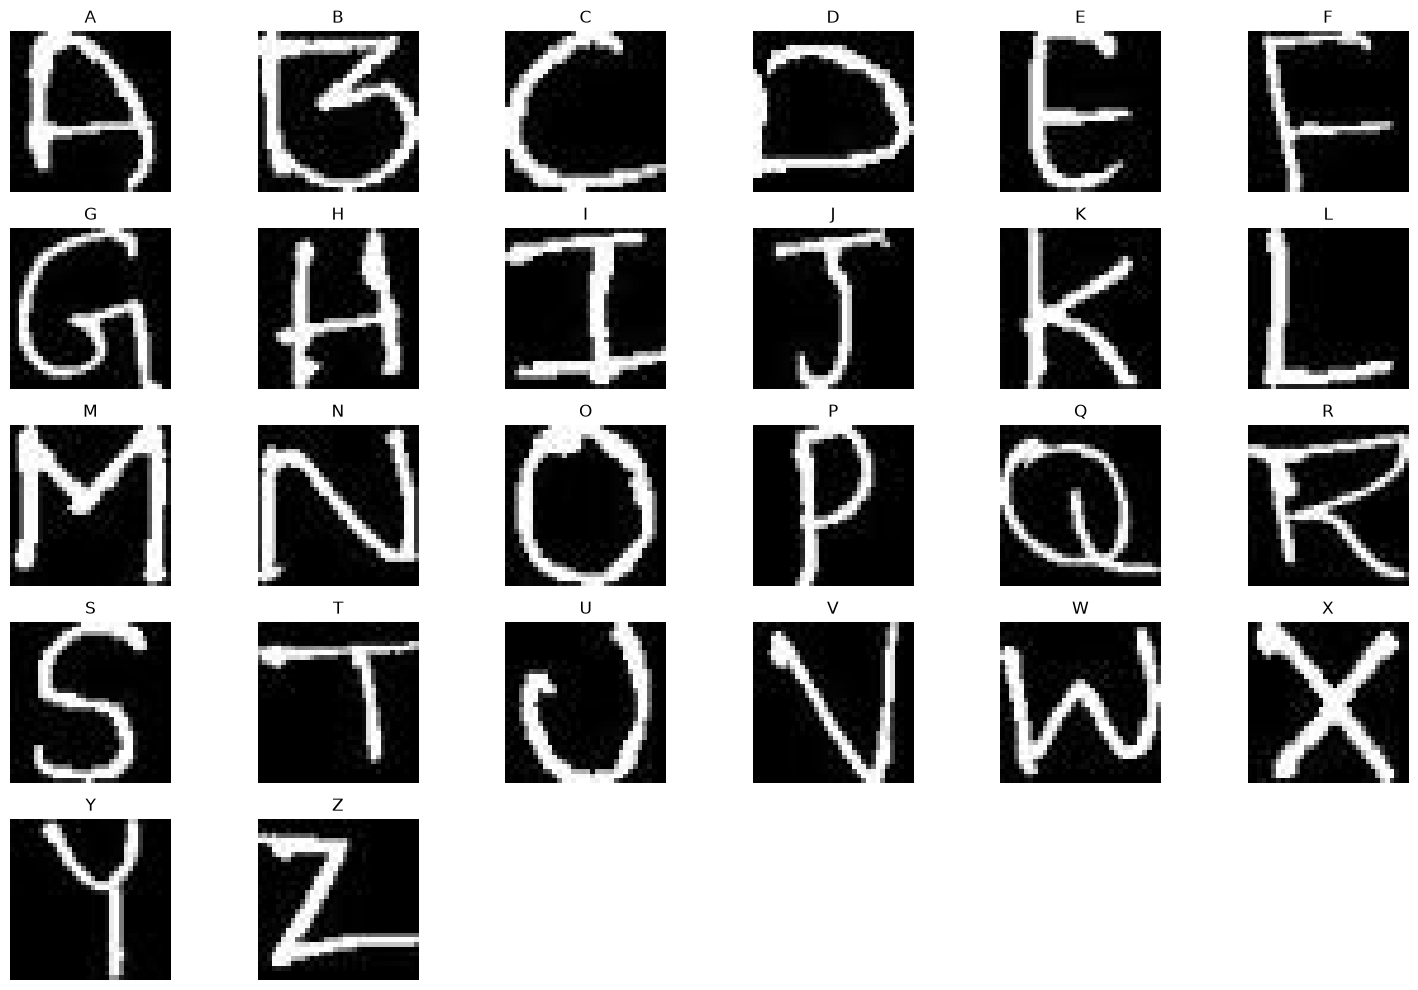

In [8]:
import cv2
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

for i, cls in enumerate(classes):
    img_name = os.listdir(os.path.join(dataset_path, cls))[0]
    img_path = os.path.join(dataset_path, cls, img_name)

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(5, 6, i+1)
    plt.imshow(image)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Display Image Dimensions

In [9]:
sample_class = classes[0]
sample_folder = os.path.join(dataset_path, sample_class)

sample_image = os.listdir(sample_folder)[0]
sample_path = os.path.join(sample_folder, sample_image)

img = cv2.imread(sample_path)

print("Image Shape :", img.shape)
print("Height :", img.shape[0])
print("Width :", img.shape[1])
print("Channels :", img.shape[2])

Image Shape : (34, 34, 3)
Height : 34
Width : 34
Channels : 3


> Observations:
- Dataset loaded successfully.
- Total images: 6831.
- Total classes: 26.
- Sample images were displayed successfully.
- Image size is 34 × 34 × 3.
> Insights:
- The dataset is organized correctly into class folders.
- Images are available for all alphabet classes.
> Recommendation:
- The dataset is ready for exploration and preprocessing.

# Dataset Exploration (EDA)

In [10]:
# Images per Class
class_counts = {}

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    class_counts[cls] = len(os.listdir(folder))

print(class_counts)

{'A': 391, 'B': 272, 'C': 297, 'D': 274, 'E': 249, 'F': 284, 'G': 250, 'H': 229, 'I': 201, 'J': 227, 'K': 217, 'L': 282, 'M': 261, 'N': 350, 'O': 292, 'P': 336, 'Q': 251, 'R': 239, 'S': 263, 'T': 226, 'U': 237, 'V': 244, 'W': 237, 'X': 272, 'Y': 210, 'Z': 240}


In [11]:
# Class Distribution
import pandas as pd

df = pd.DataFrame({
    "Class": class_counts.keys(),
    "Images": class_counts.values()
})

df

,Class,Images
0,A,391
1,B,272
2,C,297
3,D,274
4,E,249
5,F,284
6,G,250
7,H,229
8,I,201
9,J,227


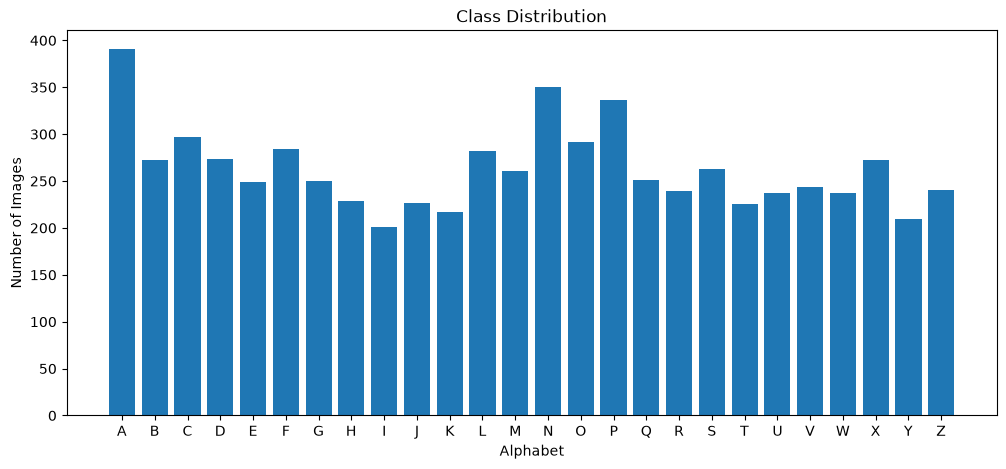

In [12]:
# class count Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.bar(df["Class"], df["Images"])

plt.title("Class Distribution")
plt.xlabel("Alphabet")
plt.ylabel("Number of Images")

plt.show()

In [13]:
# Percentage Distribution
df["Percentage"] = (df["Images"] / total_images) * 100

df

,Class,Images,Percentage
0,A,391,5.723906
1,B,272,3.981847
2,C,297,4.347826
3,D,274,4.011126
4,E,249,3.645147
5,F,284,4.157517
6,G,250,3.659786
7,H,229,3.352364
8,I,201,2.942468
9,J,227,3.323086


In [14]:
# Image Resolution
heights = []
widths = []

for cls in classes:
    folder = os.path.join(dataset_path, cls)

    for img_name in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, img_name))

        heights.append(img.shape[0])
        widths.append(img.shape[1])

print("Minimum Height :", min(heights))
print("Maximum Height :", max(heights))
print("Minimum Width :", min(widths))
print("Maximum Width :", max(widths))


Minimum Height : 34
Maximum Height : 34
Minimum Width : 34
Maximum Width : 34


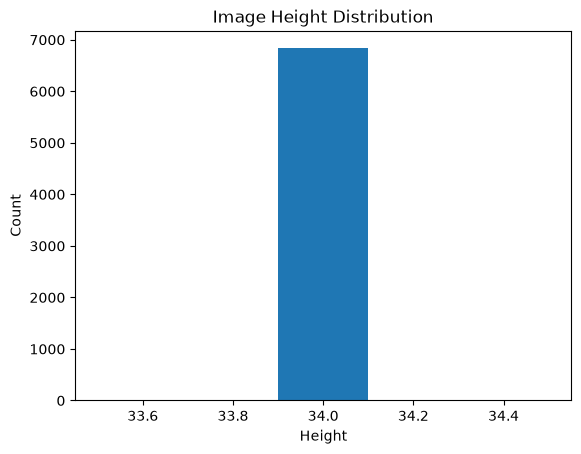

In [15]:
# Image Resolution Distribution
plt.hist(heights, bins=5)

plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Count")

plt.show()

> Observations:
- The dataset contains 6831 images across 26 classes.
- Images have a uniform size of 34 × 34 pixels.
- Images are RGB with 3 channels.
- Class distribution is slightly uneven but every class has sufficient samples.
> Insights
- Uniform image size simplifies preprocessing.
- The dataset is suitable for multiclass classification.
> Recommendation
- Normalize images before training.
- Proceed with preprocessing and feature extraction.

# Image Preprocessing

In [16]:
images = []
labels = []

image_size = (34, 34)

for cls in classes:
    folder = os.path.join(dataset_path, cls)

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)

        img = cv2.imread(img_path)

        # Skip corrupted images
        if img is None:
            continue

        # Resize image
        img = cv2.resize(img, image_size)

        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Normalize pixel values
        img = img.astype(np.float32) / 255.0

        images.append(img)
        labels.append(cls)

images = np.array(images)
labels = np.array(labels)

print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)

Images Shape : (6831, 34, 34, 3)
Labels Shape : (6831,)


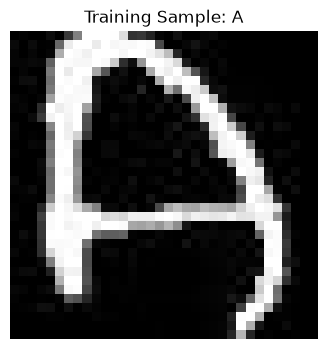

In [17]:
plt.figure(figsize=(4, 4))
plt.imshow(images[0])
plt.title(f"Training Sample: {labels[0]}")
plt.axis("off")
plt.show()

In [18]:
# Verify Pixel Values
print("Minimum Pixel Value :", images.min())
print("Maximum Pixel Value :", images.max())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


# Feature Extraction (Flatten Pixels)

In [19]:
# Feature Extraction using Flatten Pixels

X = images.reshape(images.shape[0], -1)

print("Feature Matrix Shape :", X.shape)

Feature Matrix Shape : (6831, 3468)


> Observations:
- Images were successfully converted into feature vectors.
- Each image contains 3468 numerical features.
- The feature matrix contains 6831 samples.
> Insights
- Flattening transforms image data into a format that classical machine learning algorithms can process.
- All images now have the same number of features

# Label Encoding

In [20]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(labels)

print("Target Shape :", y.shape)
print("Encoded Classes :", label_encoder.classes_)

Target Shape : (6831,)
Encoded Classes : ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


> Observations:
- Target labels were successfully encoded into numerical values.
- The target variable contains 6831 samples.
- All 26 English alphabet classes (A–Z) were encoded correctly.
> Insights
- Numerical labels allow machine learning algorithms to process the target variable.
- The dataset is now fully prepared for train-test splitting.

# Input–Output Separation

In [21]:
print("Input (X) Shape :", X.shape)
print("Output (y) Shape :", y.shape)

Input (X) Shape : (6831, 3468)
Output (y) Shape : (6831,)


> Observations:
- The input feature matrix contains 6831 samples with 3468 features each.
- The output variable contains 6831 encoded class labels.
> Insights
- The input (X) and output (y) are correctly separated.
- The dataset is now ready for splitting into training and testing sets.

# Train Test Split

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5464, 3468)
X_test : (1367, 3468)
y_train: (5464,)
y_test : (1367,)


# Model Building

In [ ]:
# ============================================================
# FINAL MODEL TRAINING - ALL 5 ALGORITHMS
# ============================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC


# ============================================================
# 1. K-NEAREST NEIGHBORS
# ============================================================

knn_model = KNeighborsClassifier(
    n_neighbors=3,
    weights="distance",
    metric="euclidean"
)

print("Training KNN...")
knn_model.fit(X_train, y_train)

print("KNN Training Completed!")


# ============================================================
# 2. NAIVE BAYES
# ============================================================

nb_model = GaussianNB()

print("\nTraining Naive Bayes...")
nb_model.fit(X_train, y_train)

print("Naive Bayes Training Completed!")


# ============================================================
# 3. DECISION TREE
# ============================================================

dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=1,
    random_state=42
)

print("\nTraining Decision Tree...")
dt_model.fit(X_train, y_train)

print("Decision Tree Training Completed!")


# ============================================================
# 4. LOGISTIC REGRESSION
# ============================================================

lr_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

print("\nTraining Logistic Regression...")
lr_model.fit(X_train, y_train)

print("Logistic Regression Training Completed!")


# ============================================================
# 5. LINEAR SVM
# ============================================================

svm_model = LinearSVC(
    C=1.0,
    max_iter=10000,
    random_state=42
)

print("\nTraining Linear SVM...")
svm_model.fit(X_train, y_train)

print("Linear SVM Training Completed!")


# ============================================================
# FINAL MESSAGE
# ============================================================

print("\n===================================")
print("ALL 5 MODELS TRAINED SUCCESSFULLY!")
print("===================================")

Training KNN...
KNN Training Completed!

Training Naive Bayes...
Naive Bayes Training Completed!

Training Decision Tree...
Decision Tree Training Completed!

Training Logistic Regression...
Logistic Regression Training Completed!

Training Linear SVM...


# Model Evaluation

In [ ]:
# ============================================================
# MODEL EVALUATION - ALL 5 ALGORITHMS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import pandas as pd


# ============================================================
# 1. PREDICTIONS
# ============================================================

y_pred_knn = knn_model.predict(X_test)
y_pred_nb = nb_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)
y_pred_lr = lr_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)


# ============================================================
# 2. STORE MODELS AND PREDICTIONS
# ============================================================

predictions = {
    "K-Nearest Neighbors": y_pred_knn,
    "Naive Bayes": y_pred_nb,
    "Decision Tree": y_pred_dt,
    "Logistic Regression": y_pred_lr,
    "Linear SVM": y_pred_svm
}


# ============================================================
# 3. EVALUATE ALL MODELS
# ============================================================

results = []

for model_name, y_pred in predictions.items():

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })


# ============================================================
# 4. CREATE COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("\nMODEL COMPARISON")
print("=" * 70)

print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# 5. BEST MODEL
# ============================================================

best_model = results_df.iloc[0]

print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)

print("Model     :", best_model["Model"])
print("Accuracy  :", round(best_model["Accuracy"], 4))
print("Precision :", round(best_model["Precision"], 4))
print("Recall    :", round(best_model["Recall"], 4))
print("F1 Score  :", round(best_model["F1 Score"], 4))




MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1 Score
K-Nearest Neighbors  0.836869   0.849908 0.836869  0.835727
Logistic Regression  0.814923   0.817254 0.814923  0.814644
         Linear SVM  0.755669   0.758681 0.755669  0.754995
        Naive Bayes  0.694952   0.722699 0.694952  0.690210
      Decision Tree  0.505486   0.510784 0.505486  0.504856

BEST MODEL
Model     : K-Nearest Neighbors
Accuracy  : 0.8369
Precision : 0.8499
Recall    : 0.8369
F1 Score  : 0.8357


# Random Forest + Hyperparameter Tuning

In [25]:
# ============================================================
# RANDOM FOREST HYPERPARAMETER TUNING WITH PIPELINE
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


# ============================================================
# 1. CREATE PIPELINE
# ============================================================

rf_pipeline = Pipeline([
    (
        "classifier",
        RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        )
    )
])


# ============================================================
# 2. HYPERPARAMETER SPACE
# ============================================================

param_dist = {

    "classifier__n_estimators": [
        200,
        300,
        500
    ],

    "classifier__max_depth": [
        None,
        20,
        30,
        40
    ],

    "classifier__min_samples_split": [
        2,
        5,
        10
    ],

    "classifier__min_samples_leaf": [
        1,
        2,
        4
    ],

    "classifier__max_features": [
        "sqrt",
        "log2"
    ],

    "classifier__class_weight": [
        None,
        "balanced"
    ]
}


# ============================================================
# 3. RANDOMIZED SEARCH CV
# ============================================================

rf_search = RandomizedSearchCV(

    estimator=rf_pipeline,

    param_distributions=param_dist,

    n_iter=15,

    scoring="accuracy",

    cv=3,

    verbose=2,

    random_state=42,

    n_jobs=-1
)


# ============================================================
# 4. START HYPERPARAMETER TUNING
# ============================================================

print(
    "Starting Random Forest Hyperparameter Tuning..."
)

rf_search.fit(
    X_train,
    y_train
)

print(
    "\nRandom Forest Hyperparameter Tuning Completed!"
)


# ============================================================
# 5. BEST PARAMETERS
# ============================================================

print("\nBest Parameters:")

print(
    rf_search.best_params_
)


# ============================================================
# 6. BEST CROSS-VALIDATION SCORE
# ============================================================

print("\nBest Cross Validation Score:")

print(
    rf_search.best_score_
)


# ============================================================
# 7. GET FINAL TUNED PIPELINE
# ============================================================

best_rf_pipeline = rf_search.best_estimator_


# ============================================================
# 8. TEST SET PREDICTION
# ============================================================

y_pred_best_rf = best_rf_pipeline.predict(
    X_test
)


# ============================================================
# 9. EVALUATION METRICS
# ============================================================

rf_accuracy = accuracy_score(
    y_test,
    y_pred_best_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_best_rf,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_best_rf,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_best_rf,
    average="weighted",
    zero_division=0
)


# ============================================================
# 10. PRINT FINAL RESULTS
# ============================================================

print("\n" + "=" * 60)

print(
    "TUNED RANDOM FOREST RESULTS"
)

print("=" * 60)

print(
    f"Accuracy  : {rf_accuracy:.4f}"
)

print(
    f"Precision : {rf_precision:.4f}"
)

print(
    f"Recall    : {rf_recall:.4f}"
)

print(
    f"F1 Score  : {rf_f1:.4f}"
)


# ============================================================
# 11. CLASSIFICATION REPORT
# ============================================================

print(
    "\nClassification Report"
)

print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_best_rf,
        zero_division=0
    )
)

Starting Random Forest Hyperparameter Tuning...
Fitting 3 folds for each of 15 candidates, totalling 45 fits



Random Forest Hyperparameter Tuning Completed!

Best Parameters:
{'classifier__n_estimators': 300, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'log2', 'classifier__max_depth': 40, 'classifier__class_weight': None}

Best Cross Validation Score:
0.8404079695498687

TUNED RANDOM FOREST RESULTS
Accuracy  : 0.8559
Precision : 0.8591
Recall    : 0.8559
F1 Score  : 0.8554

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.92      0.91        78
           1       0.78      0.87      0.82        54
           2       0.87      0.97      0.91        60
           3       0.83      0.82      0.83        55
           4       0.91      0.78      0.84        50
           5       0.94      0.81      0.87        57
           6       0.88      0.74      0.80        50
           7       0.93      0.87      0.90        46
           8       0.67      0.78      0.72        40
           9

# Confusion Matrix

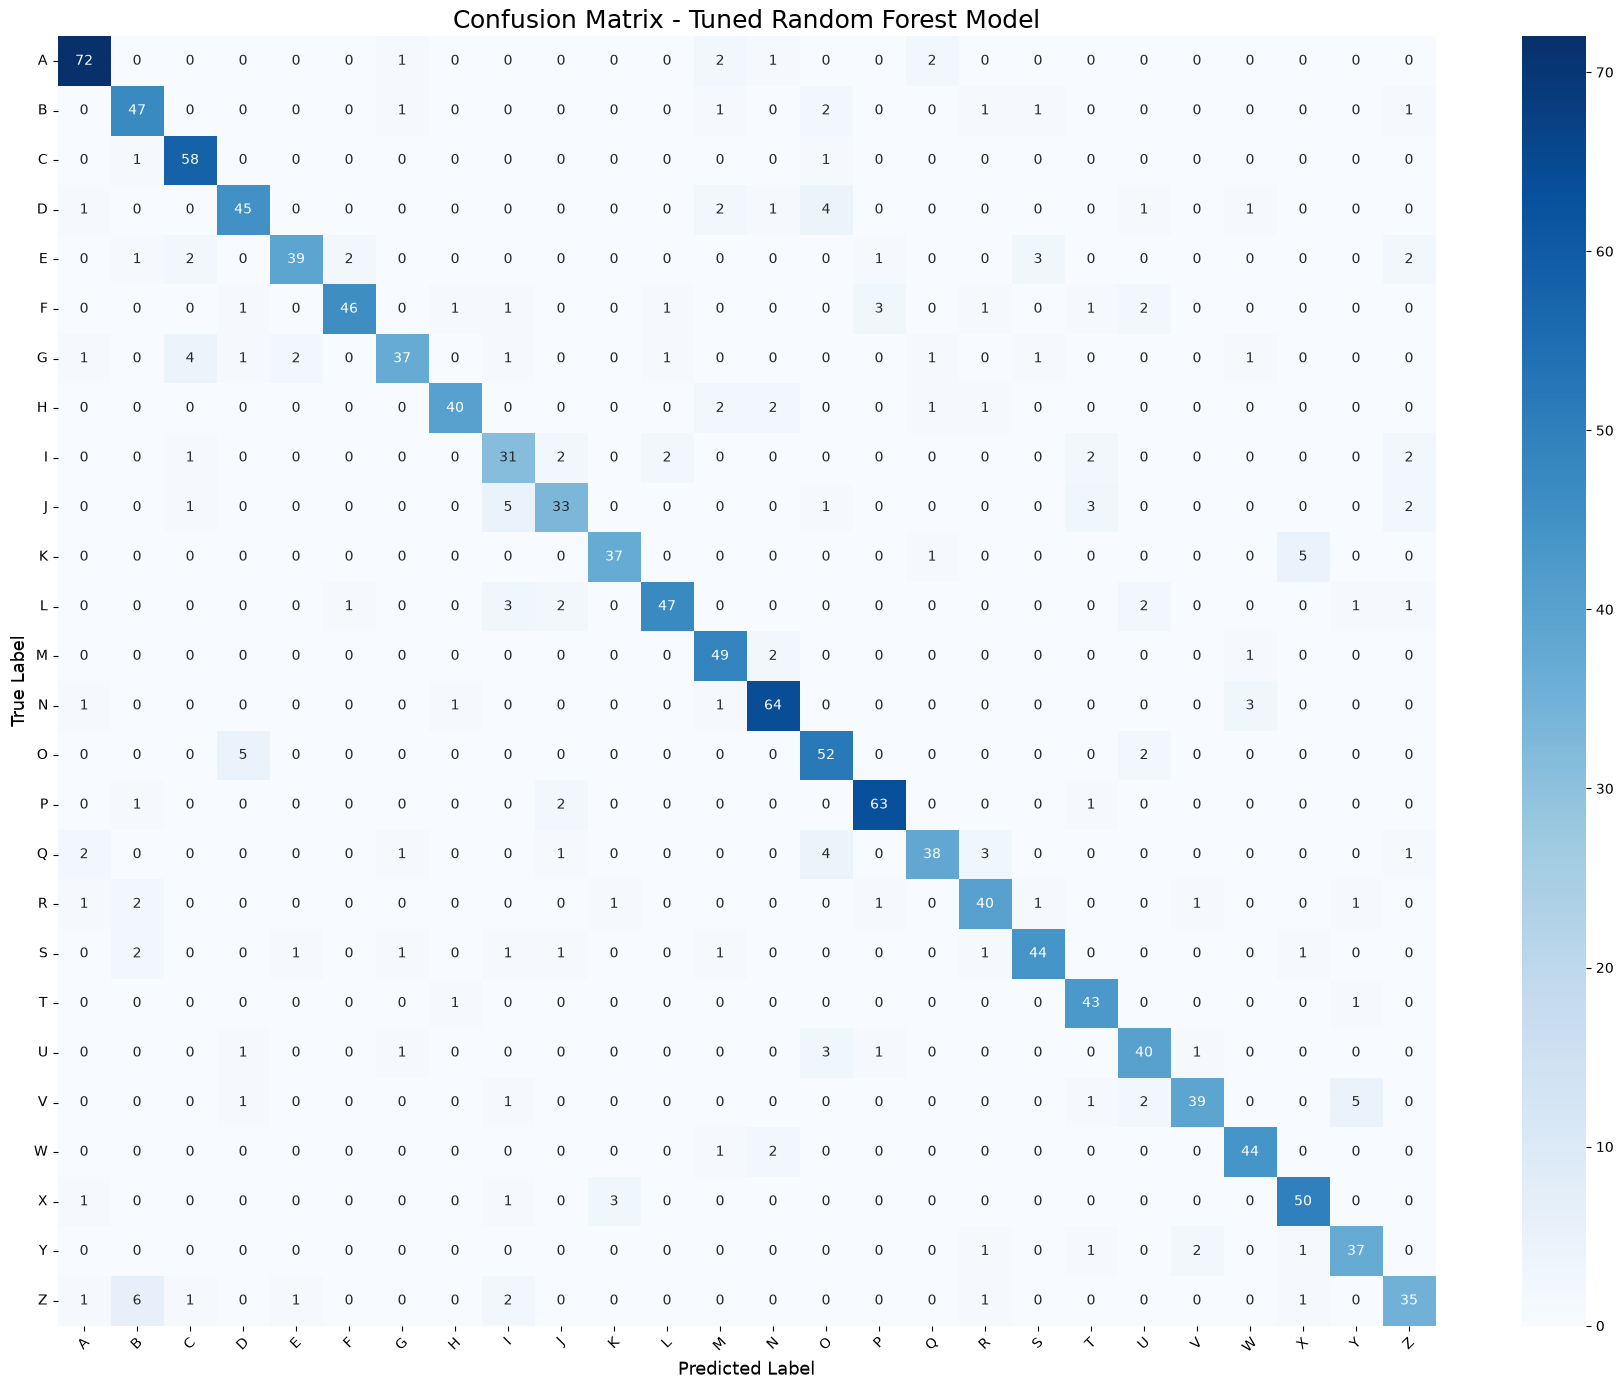

In [26]:
# ============================================================
# CONFUSION MATRIX - TUNED RANDOM FOREST
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import string


# ============================================================
# 1. CREATE CONFUSION MATRIX
# ============================================================

cm_rf = confusion_matrix(
    y_test,
    y_pred_best_rf
)


# ============================================================
# 2. CLASS LABELS A-Z
# ============================================================

class_labels = list(
    string.ascii_uppercase
)


# ============================================================
# 3. PLOT CONFUSION MATRIX
# ============================================================

plt.figure(
    figsize=(18, 14)
)

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title(
    "Confusion Matrix - Tuned Random Forest Model",
    fontsize=18
)

plt.xlabel(
    "Predicted Label",
    fontsize=13
)

plt.ylabel(
    "True Label",
    fontsize=13
)

plt.xticks(
    rotation=45
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

plt.show()

# Model Saving

In [27]:
# ============================================================
# SAVE FINAL TUNED RANDOM FOREST PIPELINE
# ============================================================

import joblib


# ============================================================
# 1. FINAL MODEL
# ============================================================

final_model = best_rf_pipeline


# ============================================================
# 2. SAVE COMPLETE PIPELINE
# ============================================================

joblib.dump(
    final_model,
    "alphabet_rf_pipeline.pkl"
)


# ============================================================
# 3. CONFIRM
# ============================================================

print("=" * 60)
print("FINAL TUNED RANDOM FOREST PIPELINE SAVED!")
print("=" * 60)

print(
    "File: alphabet_rf_pipeline.pkl"
)

FINAL TUNED RANDOM FOREST PIPELINE SAVED!
File: alphabet_rf_pipeline.pkl


In [28]:
# ============================================================
# LOAD AND VERIFY SAVED RANDOM FOREST PIPELINE
# ============================================================

import joblib
from sklearn.metrics import accuracy_score


# ============================================================
# 1. LOAD SAVED PIPELINE
# ============================================================

loaded_rf_pipeline = joblib.load(
    "alphabet_rf_pipeline.pkl"
)

print("Pipeline Loaded Successfully!")


# ============================================================
# 2. PREDICT TEST DATA
# ============================================================

loaded_predictions = loaded_rf_pipeline.predict(
    X_test
)


# ============================================================
# 3. CHECK ACCURACY
# ============================================================

loaded_accuracy = accuracy_score(
    y_test,
    loaded_predictions
)


# ============================================================
# 4. DISPLAY RESULT
# ============================================================

print("\n" + "=" * 50)
print("SAVED PIPELINE VERIFICATION")
print("=" * 50)

print(
    f"Loaded Model Accuracy: {loaded_accuracy:.4f}"
)

print(
    f"Expected Accuracy    : {rf_accuracy:.4f}"
)

Pipeline Loaded Successfully!

SAVED PIPELINE VERIFICATION
Loaded Model Accuracy: 0.8559
Expected Accuracy    : 0.8559
